In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

########################################
# 0. LOAD DATA
########################################

df = pd.read_excel(
    "/Users/Altair93/Documents/Dottorato/PATHS/Python_analisys/Intermediate_data/statistic/Database_PlanB.xlsx"
)

In [2]:
########################################
# 1. HELPER FUNCTIONS
########################################

def fit_ols(y, X):
    Xc = sm.add_constant(X)
    model = sm.OLS(y, Xc).fit()
    return model

def hierarchical_r2(outcome_name,
                    clinical_cols,
                    step2_cols,
                    step3_cols,
                    cog_cols,
                    df,
                    baseline_col):
    """
    outcome_name: string, es. 'deltabarthel' o 'deltafim'
    clinical_cols: lista feature cliniche baseline (age, sex, onset, baseline score)
    step2_cols: lista feature EEG aperiodic/slowing
    step3_cols: lista feature EEG complexity
    cog_cols: lista feature cognitive reserve
    baseline_col: solo descrittivo
    """
    y = df[outcome_name]

    steps = [
        ("Step1_Clinical", clinical_cols),
        ("Step2_+Aperiodic/Slowing", clinical_cols + step2_cols),
        ("Step3_+Complexity", clinical_cols + step2_cols + step3_cols),
        ("Step4_+Cognition", clinical_cols + step2_cols + step3_cols + cog_cols),
    ]

    r2_list = []
    model_objs = {}

    for step_name, cols in steps:
        X = df[cols]
        m = fit_ols(y, X)
        r2_list.append({
            "Outcome": "ΔBarthel" if outcome_name=="deltabarthel" else "ΔFIM",
            "Model_Step": step_name,
            "Predictors": cols,
            "R2": m.rsquared,
            "Adj_R2": m.rsquared_adj,
            "AIC": m.aic,
            "BIC": m.bic,
            "N": len(X),
            "model_obj": m
        })
        model_objs[step_name] = m

    # ΔR² vs step precedente
    for i in range(len(r2_list)):
        if i == 0:
            r2_list[i]["Delta_R2_vs_prev"] = np.nan
        else:
            r2_list[i]["Delta_R2_vs_prev"] = r2_list[i]["R2"] - r2_list[i-1]["R2"]

    return pd.DataFrame(r2_list), model_objs


def bootstrap_r2_diff(model1, model2, n_iter=10000, seed=42):
    """
    model1, model2: statsmodels OLSResults (final step per due modelli diversi sullo stesso outcome)
    Ritorna median ΔR² e CI 95%
    """
    np.random.seed(seed)
    y1 = model1.model.endog
    X1 = model1.model.exog
    y2 = model2.model.endog
    X2 = model2.model.exog

    n = len(y1)
    diffs = []
    for _ in range(n_iter):
        idx = np.random.choice(n, n, replace=True)
        m1 = sm.OLS(y1[idx], X1[idx, :]).fit()
        m2 = sm.OLS(y2[idx], X2[idx, :]).fit()
        diffs.append(m1.rsquared - m2.rsquared)

    diffs = np.array(diffs)
    return np.median(diffs), np.percentile(diffs, [2.5, 97.5])

In [4]:
########################################
# 2. DEFINE MODELS
########################################

# Clinical blocks (education esclusa)
clinical_barthel = ["age", "sex", "time_onset_eeg", "barthel_T0"]
clinical_fim     = ["age", "sex", "time_onset_eeg", "fim_T0"]

# Lesion-centered (revised):
# Step2    -> exponent_HEMI_asym, delta_HEMI_R
# Step3    -> + lziv_HEMI_R, higuci_HEMI_R
# Step4    -> + mmse, criq
step2_lesion   = ["exponent_HEMI_asym", "delta_HEMI_R"]
step3_lesion   = ["lziv_HEMI_R", "higuci_HEMI_R"]
cog_block      = ["mmse", "criq"]

# Asymmetry-based:
# Step2    -> exponent_avg, delta_HEMI_asym
# Step3    -> + lziv_HEMI_asym, higuci_HEMI_asym
step2_asym     = ["exponent_avg", "delta_HEMI_asym"]
step3_asym     = ["lziv_HEMI_asym", "higuci_HEMI_asym"]

########################################
# 3. RUN HIERARCHICAL REGRESSIONS
########################################

# ΔBARTHEL
df_barthel_lesion, models_barthel_lesion = hierarchical_r2(
    outcome_name="deltabarthel",
    clinical_cols=clinical_barthel,
    step2_cols=step2_lesion,
    step3_cols=step3_lesion,
    cog_cols=cog_block,
    df=df,
    baseline_col="barthel_T0"
)
df_barthel_lesion["Model_Type"] = "Lesion-centered"

df_barthel_asym, models_barthel_asym = hierarchical_r2(
    outcome_name="deltabarthel",
    clinical_cols=clinical_barthel,
    step2_cols=step2_asym,
    step3_cols=step3_asym,
    cog_cols=cog_block,
    df=df,
    baseline_col="barthel_T0"
)
df_barthel_asym["Model_Type"] = "Asymmetry-based"

# ΔFIM
df_fim_lesion, models_fim_lesion = hierarchical_r2(
    outcome_name="deltafim",
    clinical_cols=clinical_fim,
    step2_cols=step2_lesion,
    step3_cols=step3_lesion,
    cog_cols=cog_block,
    df=df,
    baseline_col="fim_T0"
)
df_fim_lesion["Model_Type"] = "Lesion-centered"

df_fim_asym, models_fim_asym = hierarchical_r2(
    outcome_name="deltafim",
    clinical_cols=clinical_fim,
    step2_cols=step2_asym,
    step3_cols=step3_asym,
    cog_cols=cog_block,
    df=df,
    baseline_col="fim_T0"
)
df_fim_asym["Model_Type"] = "Asymmetry-based"

# Concateno tutti i risultati stepwise
df_hier = pd.concat(
    [df_barthel_lesion, df_barthel_asym, df_fim_lesion, df_fim_asym],
    ignore_index=True
)

########################################
# 4. EXTRACT FINAL MODELS (STEP4) AND BUILD AIC/BIC TABLE
########################################

final_models = []

# Barthel final step
final_models.append({
    "Outcome": "ΔBarthel",
    "Model": "Lesion-centered",
    "stats": models_barthel_lesion["Step4_+Cognition"]
})
final_models.append({
    "Outcome": "ΔBarthel",
    "Model": "Asymmetry-based",
    "stats": models_barthel_asym["Step4_+Cognition"]
})

# FIM final step
final_models.append({
    "Outcome": "ΔFIM",
    "Model": "Lesion-centered",
    "stats": models_fim_lesion["Step4_+Cognition"]
})
final_models.append({
    "Outcome": "ΔFIM",
    "Model": "Asymmetry-based",
    "stats": models_fim_asym["Step4_+Cognition"]
})

rows = []
for fm in final_models:
    m = fm["stats"]
    rows.append({
        "Outcome": fm["Outcome"],
        "Model": fm["Model"],
        "N": int(m.nobs),
        "Predictors(k)": m.model.exog.shape[1] - 1,
        "R2": m.rsquared,
        "Adj_R2": m.rsquared_adj,
        "AIC": m.aic,
        "BIC": m.bic
    })
df_aicbic = pd.DataFrame(rows)

########################################
# 5. BOOTSTRAP ΔR² DIFFERENCES BETWEEN MODELS
########################################

barthel_median_diff, barthel_ci = bootstrap_r2_diff(
    models_barthel_lesion["Step4_+Cognition"],
    models_barthel_asym["Step4_+Cognition"]
)

fim_median_diff, fim_ci = bootstrap_r2_diff(
    models_fim_lesion["Step4_+Cognition"],
    models_fim_asym["Step4_+Cognition"]
)

print("Bootstrap R² difference (Lesion - Asymmetry)")
print(f"ΔBarthel: median ΔR² = {barthel_median_diff:.3f}, 95% CI = [{barthel_ci[0]:.3f}, {barthel_ci[1]:.3f}]")
print(f"ΔFIM:     median ΔR² = {fim_median_diff:.3f}, 95% CI = [{fim_ci[0]:.3f}, {fim_ci[1]:.3f}]")
print()

print("AIC/BIC summary:")
print(df_aicbic.round(3))
print()

Bootstrap R² difference (Lesion - Asymmetry)
ΔBarthel: median ΔR² = 0.038, 95% CI = [-0.142, 0.211]
ΔFIM:     median ΔR² = 0.028, 95% CI = [-0.122, 0.179]

AIC/BIC summary:
    Outcome            Model   N  Predictors(k)     R2  Adj_R2      AIC  \
0  ΔBarthel  Lesion-centered  31             10  0.471   0.206  283.461   
1  ΔBarthel  Asymmetry-based  31             10  0.425   0.138  286.012   
2      ΔFIM  Lesion-centered  31             10  0.591   0.386  250.585   
3      ΔFIM  Asymmetry-based  31             10  0.560   0.340  252.843   

       BIC  
0  299.235  
1  301.786  
2  266.359  
3  268.617  



In [6]:
########################################
# 6. VIF ANALYSIS
########################################

# --- Lesion-centered EEG block (final model EEG terms) ---
# usiamo le variabili EEG come appaiono nel modello lesionale revisionato:
lesion_block_cols = [
    "exponent_HEMI_asym",
    "delta_HEMI_R",
    "lziv_HEMI_R",
    "higuci_HEMI_R"
]

X_lesion = df[lesion_block_cols].copy()
X_lesion_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_lesion),
    columns=X_lesion.columns
)
X_lesion_scaled_const = X_lesion_scaled.assign(Intercept=1)

vif_lesion = pd.DataFrame({
    "Variable": X_lesion_scaled_const.columns,
    "VIF": [
        variance_inflation_factor(X_lesion_scaled_const.values, i)
        for i in range(X_lesion_scaled_const.shape[1])
    ]
})
vif_lesion = vif_lesion[vif_lesion["Variable"] != "Intercept"]
vif_lesion["Model_Block"] = "Lesion-centered"

# --- Asymmetry-based EEG block ---
asym_block_cols = [
    "exponent_avg",
    "delta_HEMI_asym",
    "lziv_HEMI_asym",
    "higuci_HEMI_asym"
]

X_asym = df[asym_block_cols].copy()
X_asym_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_asym),
    columns=X_asym.columns
)
X_asym_scaled_const = X_asym_scaled.assign(Intercept=1)

vif_asym = pd.DataFrame({
    "Variable": X_asym_scaled_const.columns,
    "VIF": [
        variance_inflation_factor(X_asym_scaled_const.values, i)
        for i in range(X_asym_scaled_const.shape[1])
    ]
})
vif_asym = vif_asym[vif_asym["Variable"] != "Intercept"]
vif_asym["Model_Block"] = "Asymmetry-based"

# combine
vif_both = pd.concat([vif_lesion, vif_asym], ignore_index=True)

print("VIF summary:")
print(vif_both.round(3))
print()

VIF summary:
             Variable    VIF      Model_Block
0  exponent_HEMI_asym  1.050  Lesion-centered
1        delta_HEMI_R  1.309  Lesion-centered
2         lziv_HEMI_R  1.311  Lesion-centered
3       higuci_HEMI_R  1.052  Lesion-centered
4        exponent_avg  1.101  Asymmetry-based
5     delta_HEMI_asym  1.061  Asymmetry-based
6      lziv_HEMI_asym  1.034  Asymmetry-based
7    higuci_HEMI_asym  1.073  Asymmetry-based



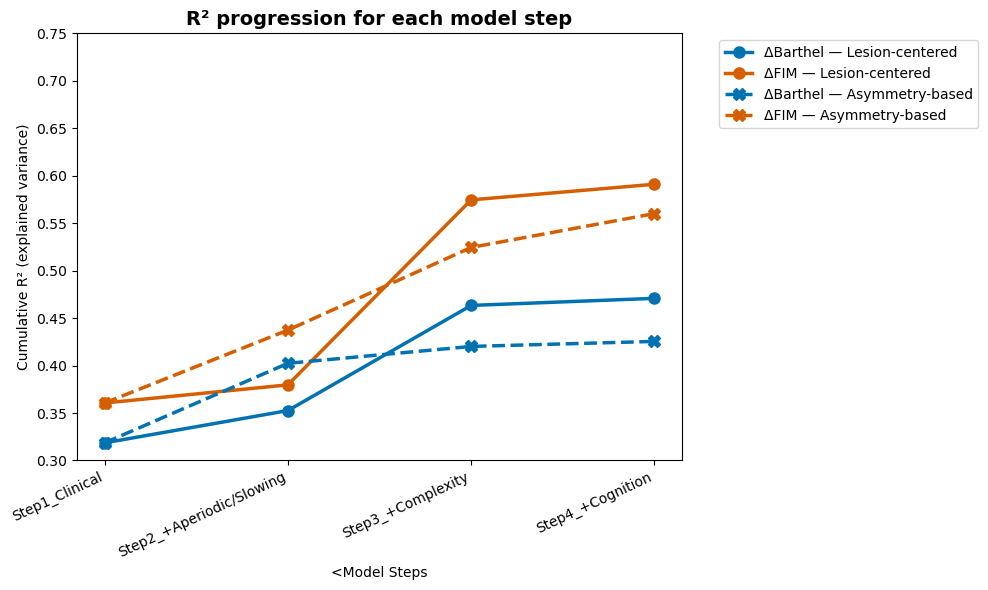

In [11]:
########################################
# 7. PLOTTING
########################################

# --- 7A. Line plot R² progression ---
plot_df = df_hier.rename(columns={
    "Model_Step": "Step",
    "Model_Type": "Model"
})

step_order = [
    "Step1_Clinical",
    "Step2_+Aperiodic/Slowing",
    "Step3_+Complexity",
    "Step4_+Cognition"
]

palette_outcome = {
    "ΔBarthel": "#0072B2",  # blu
    "ΔFIM": "#D55E00"       # arancione
}
markers_model = {
    "Lesion-centered": "o",
    "Asymmetry-based": "X"
}
linestyle_model = {
    "Lesion-centered": "-",
    "Asymmetry-based": "--"
}

plt.figure(figsize=(10,6))
for (model_name, outcome_name) in product(plot_df["Model"].unique(),
                                          plot_df["Outcome"].unique()):
    sub = plot_df[(plot_df["Model"] == model_name) &
                  (plot_df["Outcome"] == outcome_name)]
    sub = sub.set_index("Step").loc[step_order].reset_index()
    plt.plot(
        sub["Step"],
        sub["R2"],
        marker=markers_model[model_name],
        linestyle=linestyle_model[model_name],
        color=palette_outcome[outcome_name],
        linewidth=2.5,
        markersize=8,
        label=f"{outcome_name} — {model_name}"
    )

plt.title("R² progression for each model step", fontsize=14, weight="bold")
plt.ylabel("Cumulative R² (explained variance)")
plt.xlabel("<Model Steps")
plt.ylim(0.3, 0.75)
plt.xticks(rotation=25, ha='right')
plt.legend(title=None, bbox_to_anchor=(1.05,1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

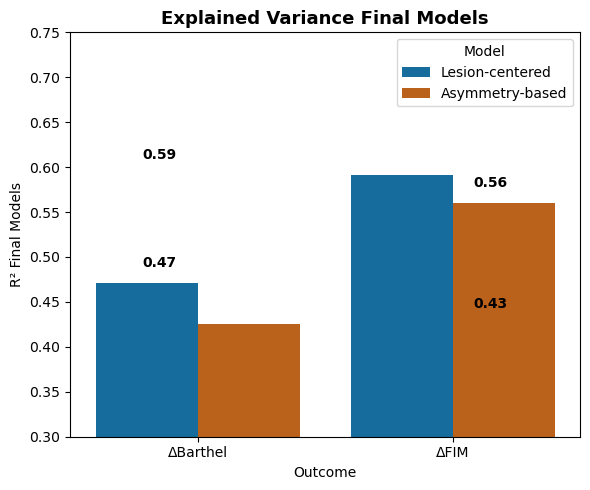

/var/folders/w2/8rzmmn057sn7_j0jxhr532cw0000gn/T/ipykernel_57536/3260726147.py:37: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


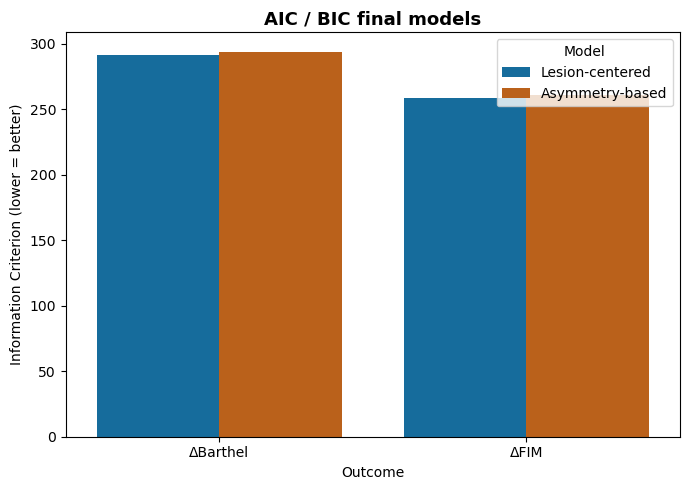

In [13]:
# --- 7B. Barplot R² finali (Step4) ---
# use the already-renamed dataframe 'plot_df' (created in previous cell)
final_r2_df = plot_df[plot_df["Step"] == "Step4_+Cognition"][["Outcome", "Model", "R2"]]

plt.figure(figsize=(6,5))
sns.barplot(
    data=final_r2_df,
    x="Outcome", y="R2",
    hue="Model",
    palette={
        "Lesion-centered":"#0072B2",
        "Asymmetry-based":"#D55E00"
    }
)
for i,row in final_r2_df.reset_index().iterrows():
    plt.text(
        x=i%2 + (-0.15 if "Lesion" in row["Model"] else 0.15),
        y=row["R2"] + 0.015,
        s=f"{row['R2']:.2f}",
        ha="center", va="bottom", fontsize=10, weight="bold"
    )
plt.ylim(0.3,0.75)
plt.ylabel("R² Final Models")
plt.title("Explained Variance Final Models", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

# --- 7C. Barplot AIC / BIC finali (Step4) ---
long_ic = df_aicbic.melt(
    id_vars=["Outcome","Model"],
    value_vars=["AIC","BIC"],
    var_name="Criterion",
    value_name="IC_value"
)

plt.figure(figsize=(7,5))
sns.barplot(
    data=long_ic,
    x="Outcome", y="IC_value",
    hue="Model",
    palette={
        "Lesion-centered":"#0072B2",
        "Asymmetry-based":"#D55E00"
    },
    ci=None
)
plt.ylabel("Information Criterion (lower = better)")
plt.title("AIC / BIC final models", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

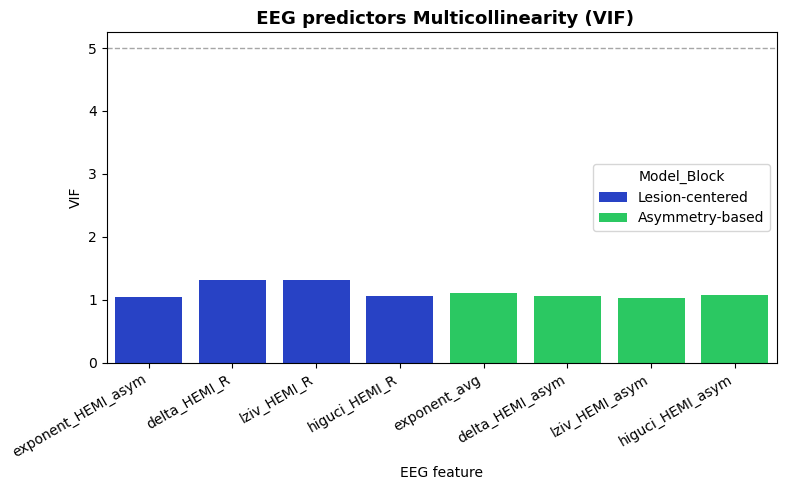

In [ ]:
# --- 7D. Barplot VIF (EEG blocks) ---
plt.figure(figsize=(8,5))
sns.barplot(
    data=vif_both,
    x='Variable', y='VIF',
    hue='Model_Block',
    palette={
        "Lesion-centered":"#0E31DFF8",
        "Asymmetry-based":"#11E25A"
    }
)
plt.axhline(5, linestyle='--', linewidth=1, color='gray', alpha=0.7)
plt.title(' EEG predictors Multicollinearity (VIF)', fontsize=13, weight='bold')
plt.ylabel('VIF')
plt.xlabel('EEG feature')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

########################################
# FINE 🎉
########################################
